In [91]:
import math
import numpy as np
import torch
from torch import nn
from torch.utils import data

In [92]:
max_degree=20
n_train,n_test=100,100
true_w=np.zeros(max_degree)
true_w[0:4]=np.array([5,1.2,-3.4,5.6])

features=np.random.normal(size=(n_train+n_test,1))
# np.random.shuffle(features)
poly_features=np.power(features,np.arange(max_degree).reshape(1,-1))
for i in range(max_degree):
  poly_features[:,i]/=math.gamma(i+1)
labels=np.dot(poly_features,true_w)
labels+=np.random.normal(scale=0.1,size=labels.shape)

In [93]:
true_w,features,poly_features,labels=[torch.tensor(x,dtype=torch.float32) for x in [true_w,features,poly_features,labels]]

In [94]:
features[:2],poly_features[:2,:],labels[:2]

(tensor([[-1.6727],
         [ 0.2547]]),
 tensor([[ 1.0000e+00, -1.6727e+00,  1.3990e+00, -7.8003e-01,  3.2619e-01,
          -1.0912e-01,  3.0422e-02, -7.2697e-03,  1.5200e-03, -2.8250e-04,
           4.7255e-05, -7.1858e-06,  1.0016e-06, -1.2888e-07,  1.5399e-08,
          -1.7172e-09,  1.7952e-10, -1.7664e-11,  1.6415e-12, -1.4451e-13],
         [ 1.0000e+00,  2.5474e-01,  3.2447e-02,  2.7552e-03,  1.7547e-04,
           8.9397e-06,  3.7956e-07,  1.3813e-08,  4.3983e-10,  1.2449e-11,
           3.1714e-13,  7.3444e-15,  1.5591e-16,  3.0552e-18,  5.5592e-20,
           9.4410e-22,  1.5031e-23,  2.2524e-25,  3.1877e-27,  4.2739e-29]]),
 tensor([-6.0006,  5.2389]))

In [100]:
def evaluate_loss(net,data_iter,loss):
  lost=0.0
  total=0
  with torch.no_grad():
    for X,y in data_iter:
      y_hat = net(X)
      y=y.reshape(y_hat.shape)
      l = loss(y_hat,y)
      lost+=l*X.shape[0]
      total+=X.shape[0]
  return (lost/total)

In [ ]:
def train(train_features,test_features,train_labels,test_labels,num_epoch=400):
  loss=nn.MSELoss()
  # loss=nn.MSELoss()
  input_shape=train_features.shape[-1]
  net=nn.Sequential(nn.Linear(input_shape,1,bias=False))
  trainer=torch.optim.SGD(net.parameters(),lr=0.01)
  train_iter=data.DataLoader(data.TensorDataset(train_features,train_labels),batch_size=10,shuffle=True)
  test_iter=data.DataLoader(data.TensorDataset(test_features,test_labels),batch_size=10,shuffle=False)
  import sys
  sys.path.append('../')
  from tools.ANIMATOR import Animator
  animator=Animator(xlabel='epoch',ylabel='loss',yscale='log',xlim=[1,num_epoch],ylim=[1e-3,1e2],
                    legend=['train','test'])
  for epoch in range(num_epoch):
    for X,y in train_iter:
      trainer.zero_grad()
      y_hat=net(X)
      l=loss(y_hat,y)
      l.backward()
      trainer.step()
    if (epoch+1)%20 ==0 or epoch==0 or epoch==num_epoch-1:
      animator.add(epoch+1,[evaluate_loss(net,train_iter,loss),evaluate_loss(net,test_iter,loss)])

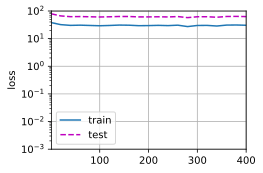

In [101]:
train(poly_features[:n_train,:4],poly_features[n_train:,:4],
labels[:n_train],labels[n_train:])

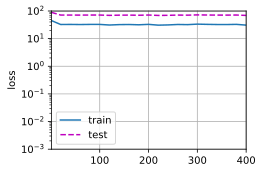

In [98]:
train(poly_features[:n_train,:2],poly_features[n_train:,:2],
labels[:n_train],labels[n_train:])

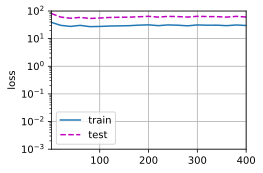

In [99]:
train(poly_features[:n_train,:],poly_features[n_train:,:],
labels[:n_train],labels[n_train:])